# PCRGlobWB Calibration Workflow

Example notebook for calibrating model parameters using optimization algorithms

In [2]:
# Imports
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
import configparser
import cma  # CMA-ES optimizer
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

from src.constants import STATIONS_PCR
from src.paths import (
    FORCING_PCRGLOB, INI_FILES, LOAD_PCR, OUTPUT_PCRGLOB,
    PCR_GLOBAL_PARAMS, PCR_TAIL,GRDC
)
import ewatercycle.forcing
import ewatercycle.parameter_sets
import ewatercycle.observation.grdc
from ewatercycle.container import ContainerImage

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


## 1. Define Parameters to Calibrate

In [3]:
# Parameters to calibrate with bounds
CALIBRATION_PARAMS = {
    'manningsN': {
        'section': 'routingOptions',
        'key': 'manningsN',
        'bounds': (0.01, 0.1),
        'initial': 0.04
    },
    'floodplainManningsN': {
        'section': 'routingOptions',
        'key': 'floodplainManningsN',
        'bounds': (0.01, 0.1),
        'initial': 0.06
    },
    'referenceepotfactor': {
        'section': 'meteoOptions',
        'key': 'referenceepotfactor',
        'bounds': (0.5, 5),
        'initial': 1.0
    },
        'precipitationFactor': {
        'section': 'meteoOptions',
        'key': 'precipitationFactor',
        'bounds': (0.5, 5),
        'initial': 1.0
    },
    'freezingT_forest': {
        'section': 'forestOptions',
        'key': 'freezingT',
        'bounds': (-5, 5),
        'initial': 0
    },
        'freezingT_grass': {
        'section': 'grasslandOptions',
        'key': 'freezingT',
        'bounds': (-5, 5),
        'initial': 0
    },



    # Add more parameters here
}

print(f"Calibrating {len(CALIBRATION_PARAMS)} parameters")
for name, info in CALIBRATION_PARAMS.items():
    print(f"  {name}: {info['bounds']} (initial: {info['initial']})")

Calibrating 6 parameters
  manningsN: (0.01, 0.1) (initial: 0.04)
  floodplainManningsN: (0.01, 0.1) (initial: 0.06)
  referenceepotfactor: (0.5, 5) (initial: 1.0)
  precipitationFactor: (0.5, 5) (initial: 1.0)
  freezingT_forest: (-5, 5) (initial: 0)
  freezingT_grass: (-5, 5) (initial: 0)


## 2. Setup Configuration

In [4]:
# Paths
# Use basin_path template for custom cloneMap/landmask
template_ini = INI_FILES / "test_comp_speed_basin_path.ini"
forcing_dir = FORCING_PCRGLOB / LOAD_PCR / PCR_TAIL
params_dir = PCR_GLOBAL_PARAMS
bmi_image = ContainerImage("/home/avandervee3/ewatercycle_pcr_17feb.sif")
output_dir = OUTPUT_PCRGLOB / "calibration_runs_5march"

# Calibration period
cal_start = "1949-10-01T00:00:00Z"
cal_end = "1950-12-31T00:00:00Z"  # Shorter for testing

# Station for calibration
station_name = "Chatly"
station_coords = STATIONS_PCR[station_name]

print(f"Station: {station_name}")
print(f"Coords: {station_coords}")
print(f"Calibration period: {cal_start} to {cal_end}")
print(f"Template INI: {template_ini.name}")

Station: Chatly
Coords: {'lat': 42.2, 'lon': 60.2}
Calibration period: 1949-10-01T00:00:00Z to 1950-12-31T00:00:00Z
Template INI: test_comp_speed_basin_path.ini


## 3. Load Observation Data

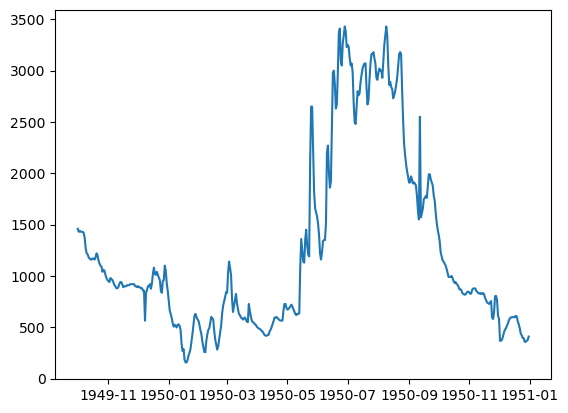

In [5]:
# Option 1: Load from GRDC
obs_data = ewatercycle.observation.grdc.get_grdc_data(
    data_home=GRDC/"Daily",
    station_id="2817100",
    start_time=cal_start,
    end_time=cal_end,
)


plt.plot(obs_data['time'], obs_data['streamflow'], label="Observed Discharge")
# # Option 2: Load from CSV
# # obs_data = pd.read_csv("observed_discharge.csv", index_col=0, parse_dates=True)

# # Option 3: Dummy data for testing
# days = (datetime.strptime(cal_end, "%Y-%m-%dT%H:%M:%SZ") - 
#         datetime.strptime(cal_start, "%Y-%m-%dT%H:%M:%SZ")).days
# obs_data = pd.Series(1000 + 200 * np.sin(np.linspace(0, 4*np.pi, days)) + 
#                       np.random.randn(days) * 50)

# print(f"Observation data: {len(obs_data)} days")
# obs_data.plot(title="Observed Discharge", ylabel="Discharge (m³/s)")
# plt.show()

In [5]:
# Custom PCRGlobWB wrapper to support custom cloneMap and landmask
from ewatercycle_pcrglobwb.model import PCRGlobWB
from pydantic import model_validator
from typing import Optional
from pathlib import Path
from ewatercycle.util import to_absolute_path

class PCRGlobWBCustom(PCRGlobWB):
    """Extended PCRGlobWB with support for custom cloneMap and landmask paths."""

    cloneMap: Optional[Path] = None
    landmask: Optional[Path] = None

    @model_validator(mode="after")
    def _check_parameter_set(self):
        if not self.parameter_set:
            return self

        target_model = self.parameter_set.target_model.lower()
        if target_model != "pcrglobwb":
            msg = (
                "Parameter set has wrong target model, "
                f"expected pcrglobwb got {target_model}"
            )
            raise ValueError(msg)

        version = self.version
        ps_versions = self.parameter_set.supported_model_versions
        if version and ps_versions and version not in ps_versions:
            msg = (
                f"Parameter set '{self.parameter_set.name}' not compatible"
                f" with this model version.\nModel version: {version}. "
                f"Compatible versions: {ps_versions}"
            )
            raise ValueError(msg)

        return self

    def _resolve_path(self, path: Path) -> Path:
        if path.is_absolute():
            return to_absolute_path(path, must_be_in_parent=False)
        return to_absolute_path(
            path, parent=self.parameter_set.directory, must_be_in_parent=True
        )

    @model_validator(mode="after")
    def _initialize_config(self: "PCRGlobWBCustom") -> "PCRGlobWBCustom":
        cfg = super()._initialize_config()._config

        # Set cloneMap if provided, otherwise use existing from config
        if self.cloneMap:
            clone_map_abs = str(self._resolve_path(self.cloneMap))
            cfg.set("globalOptions", "cloneMap", clone_map_abs)
        # If cloneMap not already in config, ensure it exists
        elif not cfg.has_option("globalOptions", "cloneMap"):
            # Try to get from parameter set directory as fallback
            # PCRGlobWB models typically have cloneMap in global options
            pass  # Let the original config handle it

        # Set landmask if provided
        if self.landmask:
            landmask_abs = str(self._resolve_path(self.landmask))
            cfg.set("globalOptions", "landmask", landmask_abs)

        self._config = cfg
        return self

    def _make_bmi_instance(self):
        if self.cloneMap:
            clone_dir = str(Path(self.cloneMap).parent)
            if clone_dir not in self._additional_input_dirs:
                self._additional_input_dirs.append(clone_dir)

        if self.landmask:
            landmask_dir = str(Path(self.landmask).parent)
            if landmask_dir not in self._additional_input_dirs:
                self._additional_input_dirs.append(landmask_dir)

        return super()._make_bmi_instance()

## 4. Helper Functions

In [6]:
def modify_ini_file(template_path, output_path, param_values):
    """Modify INI file with new parameter values"""
    config = configparser.ConfigParser()
    # Preserve case sensitivity of option names
    config.optionxform = str
    config.read(template_path)
    
    param_names = list(CALIBRATION_PARAMS.keys())
    for i, name in enumerate(param_names):
        section = CALIBRATION_PARAMS[name]['section']
        key = CALIBRATION_PARAMS[name]['key']
        
        if not config.has_section(section):
            config.add_section(section)
        
        config.set(section, key, str(param_values[i]))
    
    with open(output_path, 'w') as f:
        config.write(f)
    
    return output_path


def normalize_params(params):
    """
    Normalize parameters from their original bounds to [0, 1]
    
    Args:
        params: Array of parameter values in original scale
    
    Returns:
        Array of normalized parameter values in [0, 1]
    """
    param_names = list(CALIBRATION_PARAMS.keys())
    normalized = []
    for i, name in enumerate(param_names):
        lower, upper = CALIBRATION_PARAMS[name]['bounds']
        norm_val = (params[i] - lower) / (upper - lower)
        normalized.append(norm_val)
    return np.array(normalized)


def denormalize_params(params_normalized):
    """
    Denormalize parameters from [0, 1] back to their original bounds
    
    Args:
        params_normalized: Array of normalized parameter values in [0, 1]
    
    Returns:
        Array of parameter values in original scale
    """
    param_names = list(CALIBRATION_PARAMS.keys())
    denormalized = []
    for i, name in enumerate(param_names):
        lower, upper = CALIBRATION_PARAMS[name]['bounds']
        orig_val = params_normalized[i] * (upper - lower) + lower
        denormalized.append(orig_val)
    return np.array(denormalized)


def calculate_nse(observed, simulated):
    """Calculate Nash-Sutcliffe Efficiency"""
    mask = ~(np.isnan(observed) | np.isnan(simulated))
    obs = observed[mask]
    sim = simulated[mask]
    
    if len(obs) == 0:
        return -999
    
    numerator = np.sum((obs - sim) ** 2)
    denominator = np.sum((obs - np.mean(obs)) ** 2)
    
    if denominator == 0:
        return -999
    
    return 1 - (numerator / denominator)


def calculate_kge(observed, simulated):
    """Calculate Kling-Gupta Efficiency"""
    mask = ~(np.isnan(observed) | np.isnan(simulated))
    obs = observed[mask]
    sim = simulated[mask]
    
    if len(obs) < 2:
        return -999
    
    r = np.corrcoef(obs, sim)[0, 1]
    alpha = np.std(sim) / np.std(obs) if np.std(obs) > 0 else 0
    beta = np.mean(sim) / np.mean(obs) if np.mean(obs) > 0 else 0
    
    kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)
    return kge

print("Helper functions loaded (with parameter normalization)")

Helper functions loaded (with parameter normalization)


In [7]:
tools_folder = Path("/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/tools")
total_area = tools_folder / "aral_basin_05min.map"


## 5. Objective Function

In [8]:
# Track iterations
iteration_counter = [0]
results_log = []

def objective_function(params_normalized):
    """
    Run model with given parameters and return objective value
    
    Args:
        params_normalized: Array of normalized parameter values in [0, 1]
    
    Returns:
        float: Objective value (negative NSE, to minimize)
    """
    iteration_counter[0] += 1
    iteration = iteration_counter[0]
    
    # Denormalize parameters from [0, 1] to original scale
    params = denormalize_params(params_normalized)
    
    param_names = list(CALIBRATION_PARAMS.keys())
    param_dict = dict(zip(param_names, params))
    
    print(f"\nIteration {iteration}")
    print(f"Params: {param_dict}")
    
    try:
        # Setup run directory
        run_dir = output_dir / f"run_{iteration:04d}"
        run_dir.mkdir(parents=True, exist_ok=True)
        
        # Modify INI
        modified_ini = run_dir / "calibration.ini"
        modify_ini_file(template_ini, modified_ini, params)
        
        # Setup parameter set
        parameter_set = ewatercycle.parameter_sets.ParameterSet(
            name=f"cal_run_{iteration}",
            directory=params_dir,
            config=modified_ini,
            target_model="pcrglobwb",
            supported_model_versions={"17feb"},
        )
        
        # Load forcing data
        forcing = ewatercycle.forcing.sources["PCRGlobWBForcing"].load(
            directory=forcing_dir
        )
        
        # Create model instance using PCRGlobWBCustom
        # You can optionally add cloneMap and landmask if needed:
        # cloneMap=Path("path/to/clonemap.map"),
        # landmask=Path("path/to/landmask.map"),
        model = PCRGlobWBCustom(
            parameter_set=parameter_set,
            forcing=forcing,
            bmi_image=bmi_image,
            cloneMap=total_area,
            landmask=total_area,
        )
        
        # Setup and initialize
        config, directory = model.setup(
            cfg_dir=run_dir,
            start_time=cal_start,
            end_time=cal_end,
            max_spinups_in_years=0,
        )
        
        model.initialize(config)
        
        # Run model and collect discharge
        n_days = len(obs_data['time'])
        simulated = []
        
        for _ in tqdm(range(n_days), desc=f"Run {iteration}", leave=False):
            model.update()
            discharge = model.get_value_at_coords(
                "discharge",
                lat=[station_coords['lat']],
                lon=[station_coords['lon']],
            )
            simulated.append(discharge[0])
        
        model.finalize()
        
        # Calculate objective
        simulated = np.array(simulated)
        observed = obs_data['streamflow'].values
        
        nse = calculate_nse(observed[30:], simulated[30:])  # TODO Skip first 30 days for spinup
        kge = calculate_kge(observed[30:], simulated[30:])  # TODO Skip first 30 days for spinup
        
        print(f"NSE: {nse:.4f}, KGE: {kge:.4f}")
        
        # Log results
        results_log.append({
            'iteration': iteration,
            'nse': nse,
            'kge': kge,
            **param_dict
        })
        
        # Save results periodically
        if iteration % 4 == 0:
            df = pd.DataFrame(results_log)
            df.to_csv(output_dir / "calibration_results.csv", index=False)
        
        # Return negative NSE (for minimization)
        return -nse
    
    except Exception as e:
        print(f"ERROR: {e}")
        import traceback
        traceback.print_exc()
        return 999  # Bad fitness

print("Objective function defined (with parameter normalization)")

Objective function defined (with parameter normalization)


## 6. Run Calibration

In [ ]:
# Get initial values and bounds for CMA-ES
param_names = list(CALIBRATION_PARAMS.keys())
x0_original = [CALIBRATION_PARAMS[p]['initial'] for p in param_names]

# Normalize initial values to [0, 1]
x0_normalized = normalize_params(np.array(x0_original))

# All parameters now have bounds [0, 1]
lower_bounds = [0.0] * len(param_names)
upper_bounds = [1.0] * len(param_names)

print(f"Starting CMA-ES calibration with {len(param_names)} parameters")
print(f"Original initial values: {x0_original}")
print(f"Normalized initial values: {x0_normalized.tolist()}")
print(f"Normalized bounds: [0, 1] for all parameters")

# CMA-ES options
options = {
    'maxiter': 3,  # Number of generations (increase for real calibration)
    'popsize': 3,   # Population size per generation
    'bounds': [lower_bounds, upper_bounds],
    'verb_disp': 1,  # Display every iteration
    'verb_log': 0,   # Don't create log files
    'tolfun': 1e-6,  # Termination criterion: function value tolerance
}

# Initial step size (sigma) - now reasonable for [0, 1] space
sigma0 = 0.2  # 20% of the [0, 1] range

# Run CMA-ES optimization
es = cma.CMAEvolutionStrategy(x0_normalized.tolist(), sigma0, options)
es.optimize(objective_function)

# Get results
result = es.result
best_params_normalized = result.xbest
best_params_original = denormalize_params(np.array(best_params_normalized))
best_fitness = result.fbest

print("\n" + "="*60)
print("CMA-ES CALIBRATION COMPLETE")
print("="*60)
print(f"Best NSE: {-best_fitness:.4f}")
print(f"Total function evaluations: {result.evaluations}")
print(f"Best parameters (original scale):")
for i, name in enumerate(param_names):
    print(f"  {name}: {best_params_original[i]:.6f}")
print(f"\nBest parameters (normalized): {best_params_normalized}")

Starting CMA-ES calibration with 6 parameters
Original initial values: [0.04, 0.06, 1.0, 1.0, 0, 0]
Normalized initial values: [0.33333333333333326, 0.5555555555555555, 0.1111111111111111, 0.1111111111111111, 0.5, 0.5]
Normalized bounds: [0, 1] for all parameters
(1,3mirr1)-aCMA-ES (mu_w=1.0,w_1=100%) in dimension 6 (seed=754548, Thu Mar  5 10:07:19 2026)

Iteration 1
Params: {'manningsN': 0.047208561291460276, 'floodplainManningsN': 0.07474342365151465, 'referenceepotfactor': 1.8019738755387926, 'precipitationFactor': 1.2842917574704482, 'freezingT_forest': 1.6040640316459553, 'freezingT_grass': -3.067267750579444}


Run 1:   0%|          | 0/457 [00:00<?, ?it/s]

NSE: -48.7061, KGE: -5.1309

Iteration 2
Params: {'manningsN': 0.010473492531249788, 'floodplainManningsN': 0.05694177401345788, 'referenceepotfactor': 0.5938769460477475, 'precipitationFactor': 0.8331944176143435, 'freezingT_forest': -2.770950635645714, 'freezingT_grass': 0.663411228817413}


Run 2:   0%|          | 0/457 [00:00<?, ?it/s]

NSE: -14.3465, KGE: -2.4045

Iteration 3
Params: {'manningsN': 0.027406308848810124, 'floodplainManningsN': 0.08340291746789003, 'referenceepotfactor': 0.734658451438561, 'precipitationFactor': 1.2943088962892708, 'freezingT_forest': 1.4875654534506477, 'freezingT_grass': -2.595158036689607}


...

NSE: -104.5003, KGE: -8.0364

Iteration 6
Params: {'manningsN': 0.02101851175943882, 'floodplainManningsN': 0.049110382398558944, 'referenceepotfactor': 1.1216011054694963, 'precipitationFactor': 1.0531483521983191, 'freezingT_forest': 0.15682174563160345, 'freezingT_grass': -0.8465938416308676}


Run 6:   0%|          | 0/457 [00:00<?, ?it/s]

NSE: -28.6317, KGE: -3.7753
    2      6 2.805756125211643e+00 1.1e+00 1.89e-01  2e-01  2e-01 201:46.3

Iteration 7
Params: {'manningsN': 0.028271107516229008, 'floodplainManningsN': 0.019508128631478446, 'referenceepotfactor': 0.9735161070597877, 'precipitationFactor': 0.825669941299254, 'freezingT_forest': -4.736123446006395, 'freezingT_grass': 3.71856888100746}


Run 7:   0%|          | 0/457 [00:00<?, ?it/s]

NSE: -7.3528, KGE: -1.5328

Iteration 8
Params: {'manningsN': 0.044662777800045475, 'floodplainManningsN': 0.051294992313428024, 'referenceepotfactor': 0.6182318470558661, 'precipitationFactor': 0.7234993304502996, 'freezingT_forest': -4.051113527207111, 'freezingT_grass': 4.50087536165864}


## 7. Analyze Results

In [6]:
# Load results
results_df = pd.DataFrame(results_log)
print(results_df.sort_values('nse', ascending=False).head(10))

# Plot convergence
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# NSE over iterations
axes[0].plot(results_df['iteration'], results_df['nse'], 'o-')
axes[0].axhline(y=results_df['nse'].max(), color='r', linestyle='--', label='Best NSE')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('NSE')
axes[0].set_title('Calibration Convergence')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Parameter evolution
for param_name in CALIBRATION_PARAMS.keys():
    axes[1].plot(results_df['iteration'], results_df[param_name], 
                 'o-', label=param_name, alpha=0.7)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Parameter Value')
axes[1].set_title('Parameter Evolution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save final results
results_df.to_csv(output_dir / "calibration_results_final.csv", index=False)
print(f"\nResults saved to {output_dir / 'calibration_results_final.csv'}")

NameError: name 'results_log' is not defined

Found 7 .nc files
Filtered GRDC data to year 1950: 365 days


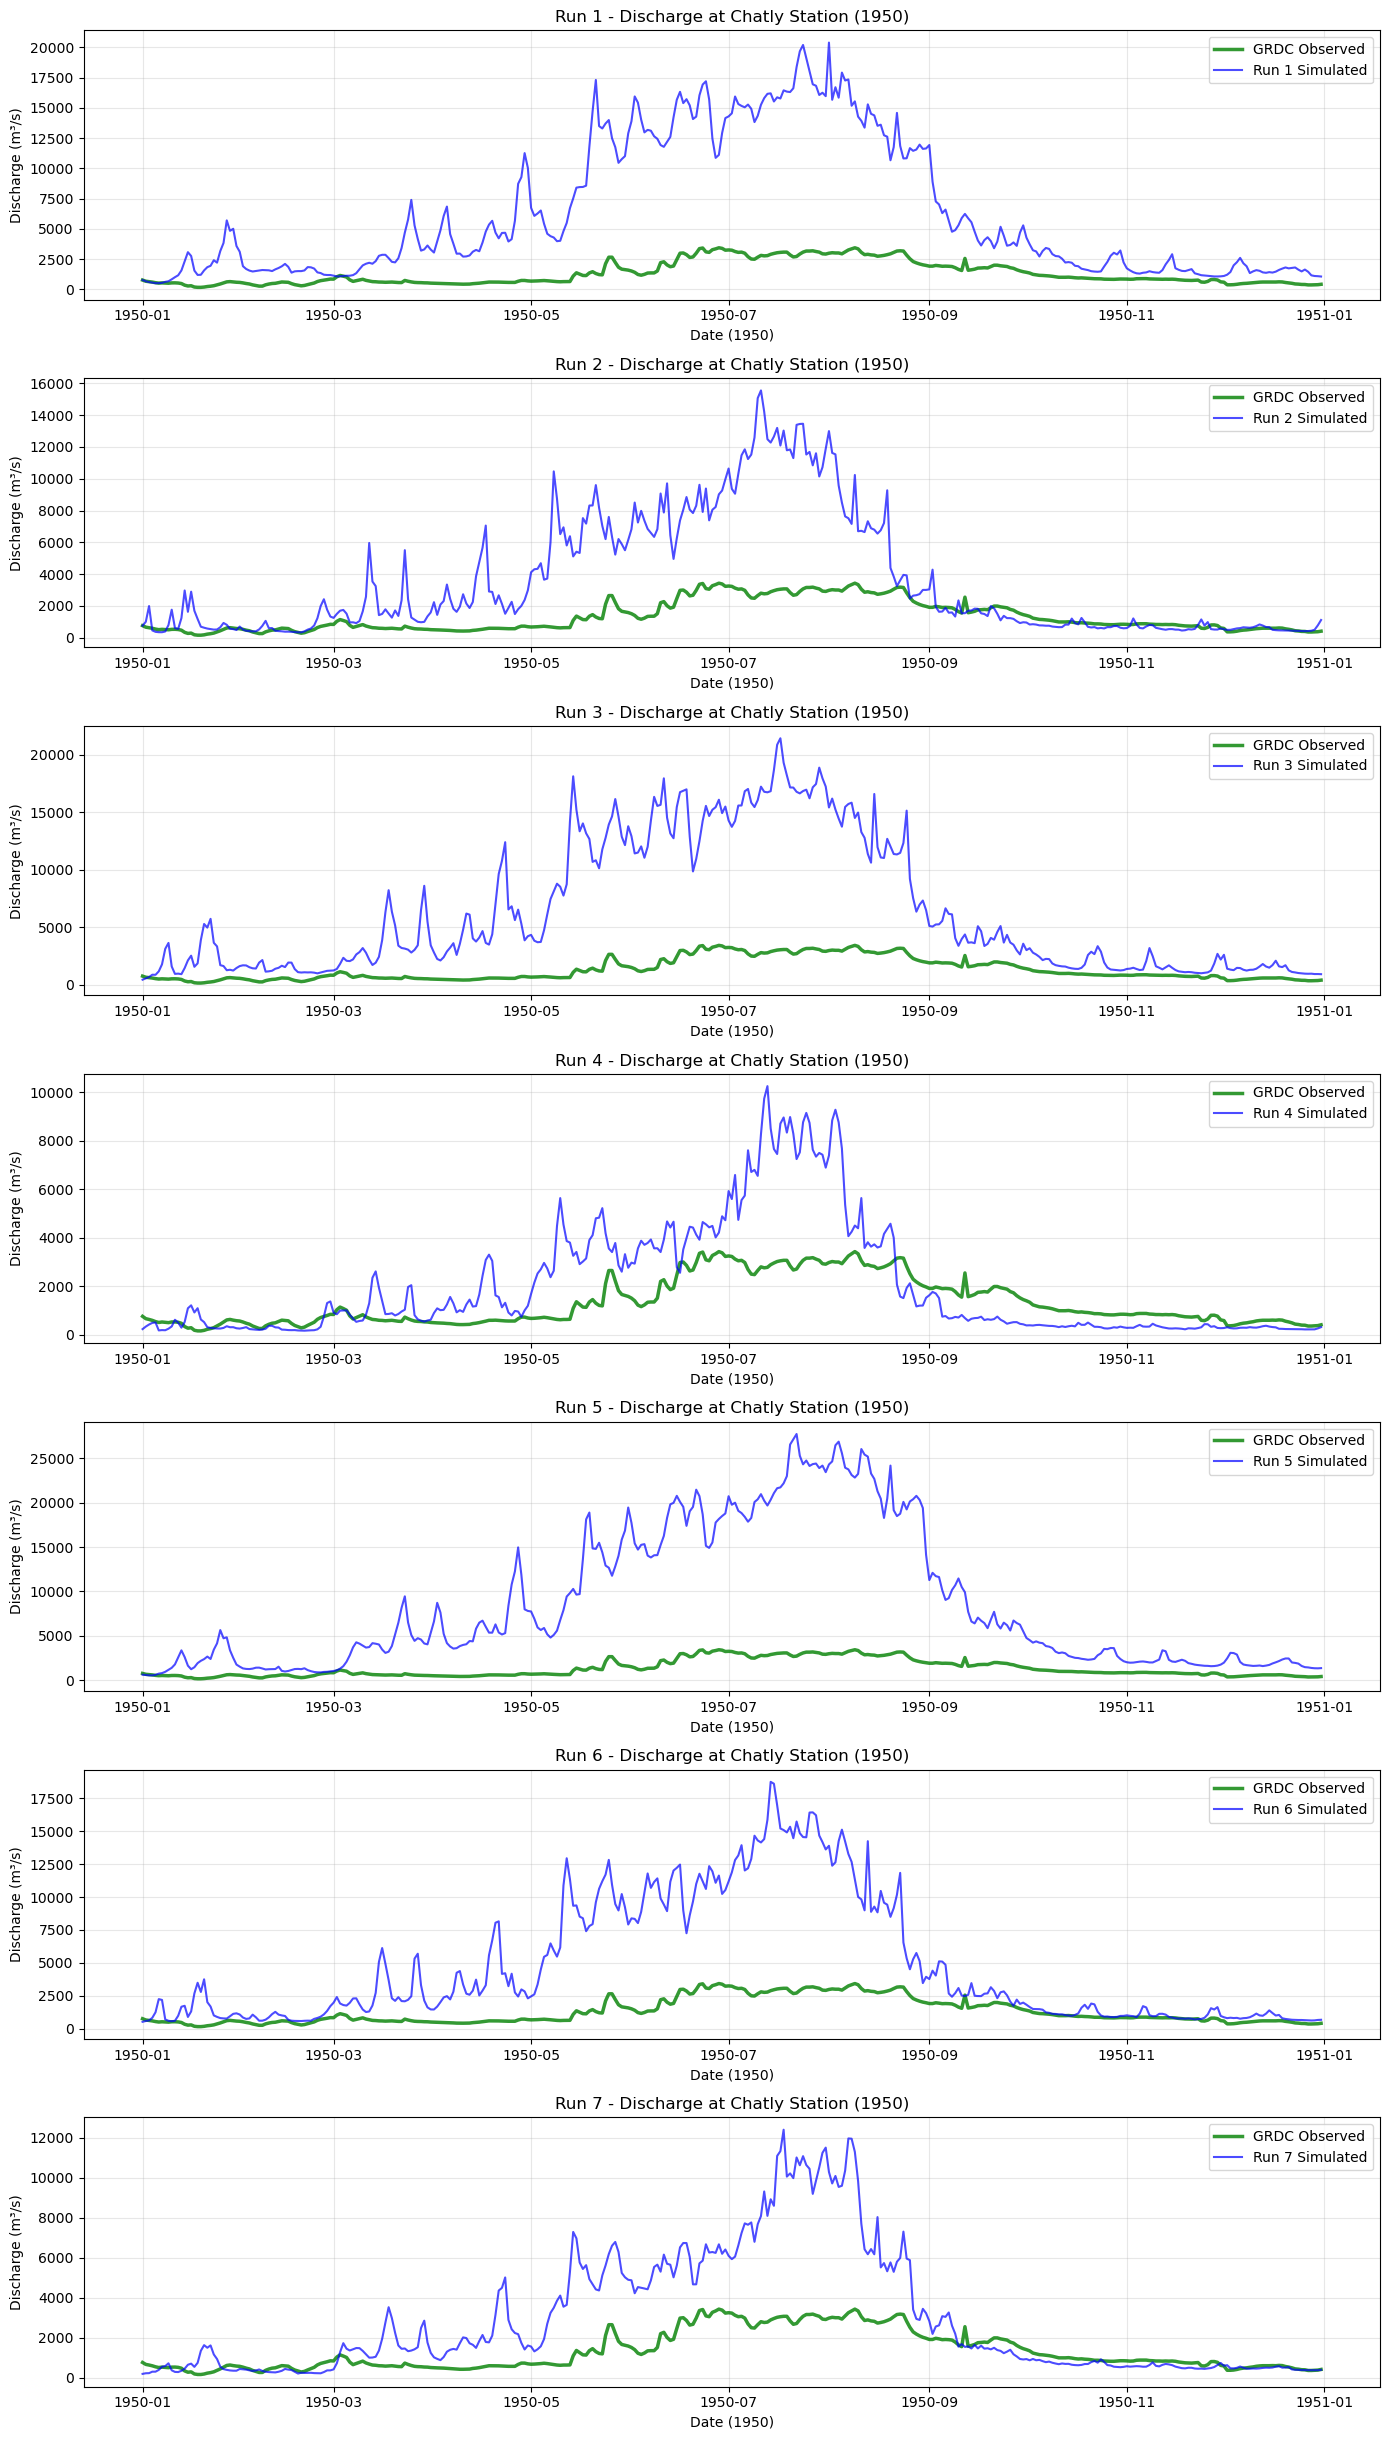


Extracted discharge time series for 7 runs at Chatly station (year 1950)


In [7]:
import xarray as xr
import glob

# Get all discharge .nc files from calibration runs
nc_files = sorted(glob.glob(str(output_dir / "run_*/netcdf/discharge_dailyTot_output.nc")))
print(f"Found {len(nc_files)} .nc files")

# Filter GRDC observations to year 1950
obs_time = pd.to_datetime(obs_data['time'].values)
mask_1950 = obs_time.year == 1950
obs_1950_streamflow = obs_data['streamflow'].values[mask_1950]
obs_time_1950 = obs_time[mask_1950]

print(f"Filtered GRDC data to year 1950: {len(obs_1950_streamflow)} days")

# Extract discharge at Chatly station for each run
fig, axes = plt.subplots(len(nc_files), 1, figsize=(14, 3.5*len(nc_files)))
if len(nc_files) == 1:
    axes = [axes]

discharge_data = {}

for idx, nc_file in enumerate(nc_files):
    run_num = int(Path(nc_file).parent.parent.name.split('_')[1])
    
    # Load netcdf file
    ds = xr.open_dataset(nc_file)
    
    # Get discharge variable (usually 'discharge' or similar)
    discharge_var = [v for v in ds.data_vars if 'discharge' in v.lower()][0]
    discharge = ds[discharge_var]
    
    # Extract value at Chatly coordinates
    station_lon = station_coords['lon']
    station_lat = station_coords['lat']
    
    # Select nearest grid point
    discharge_at_station = discharge.sel(
        lat=station_lat, 
        lon=station_lon, 
        method='nearest'
    )
    
    # Convert to numpy
    discharge_values = discharge_at_station.values
    time = discharge.time.values
    
    # Filter to year 1950
    time_pd = pd.to_datetime(time)
    mask_1950_sim = time_pd.year == 1950
    discharge_1950 = discharge_values[mask_1950_sim]
    time_1950 = time_pd[mask_1950_sim]
    
    discharge_data[run_num] = {
        'time': time_1950,
        'discharge': discharge_1950
    }
    
    # Plot both observed and simulated
    ax = axes[idx]
    ax.plot(obs_time_1950, obs_1950_streamflow, 'g-', linewidth=2.5, label='GRDC Observed', alpha=0.8)
    ax.plot(time_1950, discharge_1950, 'b-', linewidth=1.5, label=f'Run {run_num} Simulated', alpha=0.7)
    ax.set_ylabel('Discharge (m³/s)')
    ax.set_xlabel('Date (1950)')
    ax.set_title(f'Run {run_num} - Discharge at Chatly Station (1950)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    # # Get calibration metrics for this run
    # iter_results = [r for r in results_log if r['iteration'] == run_num]
    # if iter_results:
    #     nse = iter_results[0]['nse']
    #     kge = iter_results[0]['kge']
    #     ax.text(0.02, 0.95, f'NSE: {nse:.4f}\nKGE: {kge:.4f}', 
    #             transform=ax.transAxes, verticalalignment='top',
    #             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
    #             fontsize=10)
    
    ds.close()

plt.tight_layout()
plt.show()

print(f"\nExtracted discharge time series for {len(discharge_data)} runs at Chatly station (year 1950)")

In [ ]:
obs_data